# Task 1

## Answer 1.a

The Lagrangian is given by
$$L(\omega,\lambda,\gamma)=\frac{1}{2}\omega^{\top}\Sigma\omega + \lambda(m-\omega^{\top}\mu)+\gamma(1-\omega^{\top}\mathbf{1})$$

The first-order conditions are
$$
\begin{aligned}
\frac{\partial L}{\partial \omega}(\omega,\lambda,\gamma) &= \Sigma\omega - \lambda\mu - \gamma\mathbf{1} = 0 \\
\\
\frac{\partial L}{\partial \lambda}(\omega,\lambda,\gamma) &= m - \omega^{\top}\mu = 0 \\
\\
\frac{\partial L}{\partial \gamma}(\omega,\lambda,\gamma) &= 1 - \omega^{\top}\mathbf{1} = 0
\end{aligned}
$$

---

## Answer 1.b

The intermediate quantities A, B, C, and D are defined as follows:

$$A = \mathbf{1}^{\top}\Sigma^{-1}\mathbf{1}$$

$$B = \mu^{\top}\Sigma^{-1}\mathbf{1}$$

$$C = \mu^{\top}\Sigma^{-1}\mu$$

$$D = AC - B^2$$

Accordingly, the key step is to compute $\Sigma$ and its inverse.

The vector of expected returns is given by:
$$
\mu=\begin{pmatrix}
0.02 \\
0.07 \\
0.15 \\
0.20
\end{pmatrix}
$$

In [79]:
import numpy as np
mu = np.array([[0.02],
               [0.07],
               [0.15],
               [0.20]])

The standard deviation matrix $S$ is given by:

$$
S=\begin{pmatrix}
0.05 & 0 & 0 & 0 \\
0 & 0.12 & 0 & 0 \\
0 & 0 & 0.17 & 0 \\
0 & 0 & 0 & 0.25 \\
\end{pmatrix}
$$

In [80]:
S = np.array([[0.05, 0, 0, 0],
              [0, 0.12, 0, 0],
              [0, 0, 0.17, 0],
              [0, 0, 0, 0.25]])

The correlation matrix $R$ is given by:

In [81]:
R = np.array([[1, 0.3, 0.3, 0.3],
              [0.3, 1, 0.6, 0.6],
              [0.3, 0.6, 1, 0.6],
              [0.3, 0.6, 0.6, 1]])

Hence, the covariance matrix $\Sigma$ is

$$\Sigma = SRS^{\top} = SRS =
\begin{pmatrix}
0.0025 & 0.0018 & 0.00255 & 0.00375 \\
0.0018 & 0.0144 & 0.01224 & 0.018 \\
0.00255 & 0.01224 & 0.0289 & 0.0255 \\
0.00375 & 0.018 & 0.0255 & 0.0625 \\
\end{pmatrix}
$$

and its inverse is

$$\Sigma^{-1}=
\begin{pmatrix}
455.95854922 & -25.90673575 & -18.28710759 & -12.43523316 \\
-25.90673575 & 127.73459988 & -32.38341969 & -22.02072539 \\
-18.28710759 & -32.38341969 &  63.64630582 & -15.54404145 \\
-12.43523316 & -22.02072539 & -15.54404145 &  29.43005181 \\
\end{pmatrix}
$$

In [82]:
SRS = S @ R @ S
SRS

array([[0.0025 , 0.0018 , 0.00255, 0.00375],
       [0.0018 , 0.0144 , 0.01224, 0.018  ],
       [0.00255, 0.01224, 0.0289 , 0.0255 ],
       [0.00375, 0.018  , 0.0255 , 0.0625 ]])

In [83]:
SRS_inv = np.linalg.inv(SRS)
SRS_inv

array([[455.95854922, -25.90673575, -18.28710759, -12.43523316],
       [-25.90673575, 127.73459988, -32.38341969, -22.02072539],
       [-18.28710759, -32.38341969,  63.64630582, -15.54404145],
       [-12.43523316, -22.02072539, -15.54404145,  29.43005181]])


Substituting these values yields

$$A = \mathbf{1}^{\top}\Sigma^{-1}\mathbf{1} = 423.6150$$

$$B = \mu^{\top}\Sigma^{-1}\mathbf{1} = 6.8070$$

$$C = \mu^{\top}\Sigma^{-1}\mu = 0.9065$$

$$D = AC - B^2 = 337.6752$$

In [84]:
I = np.array([[1],
              [1],
              [1],
              [1]])

A = I.T @ SRS_inv @ I
print(f'A: {A[0][0]:.4f}')

B = mu.T @ SRS_inv @ I
print(f'B: {B[0][0]:.4f}')

C = mu.T @ SRS_inv @ mu
print(f'C: {C[0][0]:.4f}')

D = A * C - B**2
print(f'D: {D[0][0]:.4f}')

A: 423.6150
B: 6.8070
C: 0.9065
D: 337.6752


---

## Answer 1.c

First, verify that the portfolio weights sum to one:

$$\omega_A + \omega_B + \omega_C + \omega_D = 0.7851 + 0.0539 + 0.1336 + 0.0275 = 1.0001 \approx 1$$

The slight discrepancy from 1 is due to rounding.

In [85]:
w = np.array([[0.7851],
              [0.0539],
              [0.1336],
              [0.0275]])

sum = I.T @ w
print(f'The sum of the weights is: {sum[0][0]}')

The sum of the weights is: 1.0001


The portfolio expected return is

$$
\mu_{\pi} = \mu^{\top}\omega=
\begin{pmatrix}
0.02 \\
0.07 \\
0.15 \\
0.20
\end{pmatrix}^{\top}
\begin{pmatrix}
0.7851 \\
0.0539 \\
0.1336 \\
0.0275
\end{pmatrix}
= 0.045015 = 4.5015\% \approx 4.50\%
$$

Thus, the expected return of the portfolio is approximately 4.50%.

In [86]:
expect_return = mu.T @ w
print(f'The expected return of the portfolio is: {expect_return[0][0]}')

The expected return of the portfolio is: 0.045015


Hence, both the expected-return and full-investment constraints are satisfied.

The portfolio variance can then be computed directly:


$$
\sigma_{\pi}^2 = \omega^{\top}\Sigma\omega =
\begin{pmatrix}
0.7851 \\
0.0539 \\
0.1336 \\
0.0275 \\
\end{pmatrix}^{\top}
\begin{pmatrix}
0.0025 & 0.0018 & 0.00255 & 0.00375 \\
0.0018 & 0.0144 & 0.01224 & 0.018 \\
0.00255 & 0.01224 & 0.0289 & 0.0255 \\
0.00375 & 0.018 & 0.0255 & 0.0625 \\
\end{pmatrix}
\begin{pmatrix}
0.7851 \\
0.0539 \\
0.1336 \\
0.0275 \\
\end{pmatrix} 
= 0.003412
$$

$\sigma_{\pi} = 5.84\%$, which is consistent with the stated result.

Therefore, the result is confirmed.

In [87]:
variance = w.T @ SRS @ w
sd = np.sqrt(variance)
print(f'variance: {variance[0][0]}, sd: {sd[0][0]}')

variance: 0.0034121104922000003, sd: 0.05841327325360222


---

## Answer 1.d

### Explanation 1: Volatility

Asset A has the lowest individual volatility among the four assets, so a minimum-variance portfolio naturally assigns a relatively large weight to it.

### Explanation 2: Correlation Structure

Asset A's correlation coefficients with the other assets are all 0.3, which is lower than the 0.6 correlation among B, C, and D. 

This stronger diversification effect helps reduce overall portfolio variance.

---

# Task 2

## Answer 2.a

Using the definition of marginal VaR,

$$\frac{\partial VaR(\omega)}{\partial \omega_i}=\mu_i+z_\alpha \frac{(\Sigma\omega)_i}{\sqrt{\omega^{\top}\Sigma\omega}}$$

the result can be verified by computing the marginal VaR vector and comparing it with the values stated in the question.

$$\text{marginal VaR vector} = \mu + z_\alpha \frac{\Sigma\omega}{\sqrt{\omega^{\top}\Sigma\omega}}$$

The calculation therefore begins with $\Sigma\omega$ and $\sqrt{\omega^{\top}\Sigma\omega}$.

The quantities provided in the question are defined below.

$\mu$ vector:

$$
\mu=\begin{pmatrix}
0 \\
0 \\
0 \\
\end{pmatrix}
$$

$\sigma$ vector:

$$
\sigma=\begin{pmatrix}
0.30 \\
0.20 \\
0.15 \\
\end{pmatrix}
$$

$$
S=\begin{pmatrix}
0.30 & 0 & 0\\
0 & 0.20 & 0 \\
0 & 0 & 0.15 \\
\end{pmatrix}
$$

$\omega$ vector:

$$
\omega=\begin{pmatrix}
0.50 \\
0.20 \\
0.30 \\
\end{pmatrix}
$$

$\rho$ matrix:

$$
R=\begin{pmatrix}
1.0 & 0.8 & 0.5 \\
0.8 & 1.0 & 0.3 \\
0.5 & 0.3 & 1.0 \\
\end{pmatrix}
$$

In [88]:
import numpy as np

mu = np.array([[0],
               [0],
               [0]])

sd = np.array([[0.30],
               [0.20],
               [0.15]])

S = np.diag(sd.flatten())

w = np.array([[0.5],
              [0.2],
              [0.3]])

R = np.array([[1.0, 0.8, 0.5],
              [0.8, 1.0, 0.3],
              [0.5, 0.3, 1.0]])

This gives
$$\Sigma = SRS^{\top} = SRS =
\begin{pmatrix}
0.0900	& 0.0480	& 0.0225 \\
0.0480	& 0.0400	& 0.0090 \\
0.0225	& 0.0090	& 0.0225 \\
\end{pmatrix}
$$

In [89]:
SRS = S @ R @ S
SRS

array([[0.09  , 0.048 , 0.0225],
       [0.048 , 0.04  , 0.009 ],
       [0.0225, 0.009 , 0.0225]])

Hence,

$$\Sigma\omega=
\begin{pmatrix}
0.0900	& 0.0480	& 0.0225 \\
0.0480	& 0.0400	& 0.0090 \\
0.0225	& 0.0090	& 0.0225 \\
\end{pmatrix}
\begin{pmatrix}
0.5 \\
0.2 \\
0.3 \\
\end{pmatrix}
=\begin{pmatrix}
0.0614 \\
0.0347 \\
0.0198 \\
\end{pmatrix}
$$

In [90]:
sigma_w = SRS @ w
sigma_w

array([[0.06135],
       [0.0347 ],
       [0.0198 ]])

Moreover,

$$
\omega^{\top}\Sigma\omega=
\begin{pmatrix}
0.5 \\
0.2 \\
0.3 \\
\end{pmatrix}^{\top}
\begin{pmatrix}
0.0900	& 0.0480	& 0.0225 \\
0.0480	& 0.0400	& 0.0090 \\
0.0225	& 0.0090	& 0.0225 \\
\end{pmatrix}
\begin{pmatrix}
0.5 \\
0.2 \\
0.3 \\
\end{pmatrix}
=0.043555
$$

$$\sqrt{\omega^{\top}\Sigma\omega}=0.20869835$$

In [91]:
w_sigma_w = w.T @ sigma_w
w_sigma_w_sqrt = np.sqrt(w_sigma_w)
print(f'w_sigma_w: {w_sigma_w}, w_sigma_w_sqrt: {w_sigma_w_sqrt}')

w_sigma_w: [[0.043555]], w_sigma_w_sqrt: [[0.20869835]]


Finally, we compute the marginal VaR vector:

$$\mu + z_\alpha \frac{\Sigma\omega}{\sqrt{\omega^{\top}\Sigma\omega}}$$

In [92]:
z = -2.326
sensitivity = mu + z * sigma_w / w_sigma_w_sqrt
sensitivity

array([[-0.68376248],
       [-0.38674096],
       [-0.2206764 ]])

Hence, the three marginal VaR sensitivities are

$$\frac{\partial VaR}{\partial \omega_1} = -0.68376248$$
$$\frac{\partial VaR}{\partial \omega_2} = -0.38674096$$
$$\frac{\partial VaR}{\partial \omega_3} = -0.22067640$$

These values agree with those given in the question.

---


## Answer 2.b
1. All three assets are positively correlated with the portfolio, so increasing the weight of any asset increases portfolio volatility and tail risk.
Since $z_\alpha < 0$ and the expected returns are zero, the risk term dominates, so the marginal VaR and marginal ES sensitivities are negative.

2. A negative sensitivity means that an increase in the weight of that asset makes portfolio VaR more negative, implying a larger potential loss and therefore greater portfolio risk.


---


## Answer 2.c
Asset 1 has the largest value of $(\Sigma\omega)_i$, reflecting both its relatively high volatility and its strong contribution to overall portfolio risk. Therefore, it has the most negative marginal VaR sensitivity.

---

## Answer 2.d
### Mathematical reason

Since $\mu_i = 0$, it is sufficient to compare the absolute values of $|z_\alpha|$ and $\left|\frac{\phi(z_\alpha)}{1-c}\right|$.

Since

$$|z_\alpha| = 2.326$$

$$\left|\frac{\phi(z_\alpha)}{1-c}\right| = \left|\frac{0.02667}{0.01}\right| = 2.667$$

Thus

$$\left|\frac{\phi(z_\alpha)}{1-c}\right| > |z_\alpha|$$

Therefore,

$$\left|\frac{\partial ES}{\partial \omega_i}\right| > \left|\frac{\partial VaR}{\partial \omega_i}\right|$$


### Definitions of VaR and ES
VaR only captures the quantile threshold, whereas ES measures the average loss beyond that threshold. ES is therefore more sensitive to tail risk.

Therefore, changes in marginal weights have a larger impact on ES.

---

# Task 3

## Answer 3.a

The backtest compares the predicted 10-day 99% VaR on date $t$ with the forward 10-day log return.

Define the daily log return as
$$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right)$$

Using the most recent 21 daily returns, the rolling volatility estimate is
$$\sigma_t = \operatorname{STDEV.S}(r_{t-20}, \ldots, r_t)$$

The predicted 10-day VaR is then
$$\mathrm{VaR}^{(10)}_t = \Phi^{-1}(0.01)\ * \sigma_t\ * \sqrt{10}$$

Tforward 10-day log return is computed as
$$r^{10D}_t = \ln\left(\frac{S_{t+10}}{S_{t}}\right)$$

A breach occurs whenever
$$r^{10D}_t < \mathrm{VaR}_t$$

The implementation is shown below.

First, import the required Python packages.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define the relevant constants.

In [94]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load the index data from the Excel file.

In [95]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [96]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute the forward 10-day log return.

In [97]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-10) / data['^GSPC'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875
2015-10-16,2033.109985,4438.620117,0.004560,0.022494
2015-10-19,2033.660034,4462.069824,0.000271,0.034027
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Compute the 21D rolling standard deviation.

In [98]:
data['SD'] = data['LogReturn'].rolling(rolling_window, min_periods=rolling_window).std()
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD
Date,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875,NaN
2015-10-16,2033.109985,4438.620117,0.004560,0.022494,NaN
2015-10-19,2033.660034,4462.069824,0.000271,0.034027,NaN
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173,NaN
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464,NaN
...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642


Compute the 10-day VaR series and the breach indicator.

In [99]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875,NaN,NaN,0
2015-10-16,2033.109985,4438.620117,0.004560,0.022494,NaN,NaN,0
2015-10-19,2033.660034,4462.069824,0.000271,0.034027,NaN,NaN,0
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173,NaN,NaN,0
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464,NaN,NaN,0
...,...,...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622,-0.048713,0
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643,-0.048872,0
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642,-0.048865,0


Restrict the sample to the period from 2025-01-01 to 2026-01-15, and retain only observations for which both the VaR forecast and the realised forward 10-day return are available.

In [100]:
data = data.loc['2025-01-01':'2026-01-15'].copy()
backtest_data = data.dropna(subset=['VaR', 'Forward10dReturn']).copy()
total_count = backtest_data.shape[0]
print(f'Total count of observations: {total_count}')
backtest_data

Total count of observations: 260


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.009015,-0.066318,0
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.009511,-0.069972,0
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.009494,-0.069840,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.009755,-0.071766,0
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.009739,-0.071647,0
...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.005953,-0.043792,0
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.005804,-0.042694,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.005819,-0.042811,0


Extract the rows corresponding to VaR breaches.

In [101]:
data_breach = backtest_data[backtest_data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 10


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-02-18,6129.580078,22164.609375,0.002442,-0.059043,0.006966,-0.051246,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.050319,0.006699,-0.049282,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.063955,0.006566,-0.048305,1
2025-02-24,5983.250000,21352.080078,-0.004981,-0.063601,0.007416,-0.054557,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.066507,0.007449,-0.054799,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.061768,0.006774,-0.049834,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.059764,0.007199,-0.052963,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.110613,0.012759,-0.093862,1
2025-03-24,5767.569824,20180.449219,0.017492,-0.130440,0.013154,-0.096770,1


In [102]:
print(f'Count of breaches: {breach_count}, total count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 10, total count: 260, breach percentage: 3.85%


Hence, the valid backtesting sample contains 10 VaR breaches, corresponding to 3.86% of the 259 valid observations.

---

## Answer 3.b

Two plots are shown below.

The first plot compares the predicted 10-day VaR with the realised forward 10-day return and highlights the breach observations with black crosses.

The second plot shows the S&P 500 index level over the same sample period.

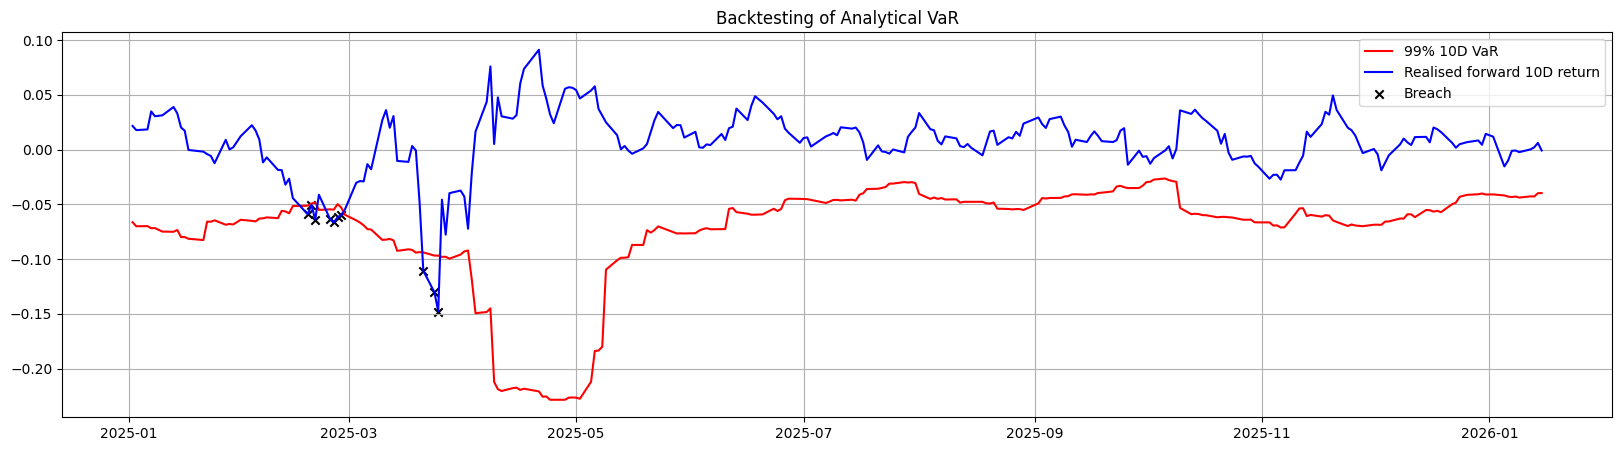

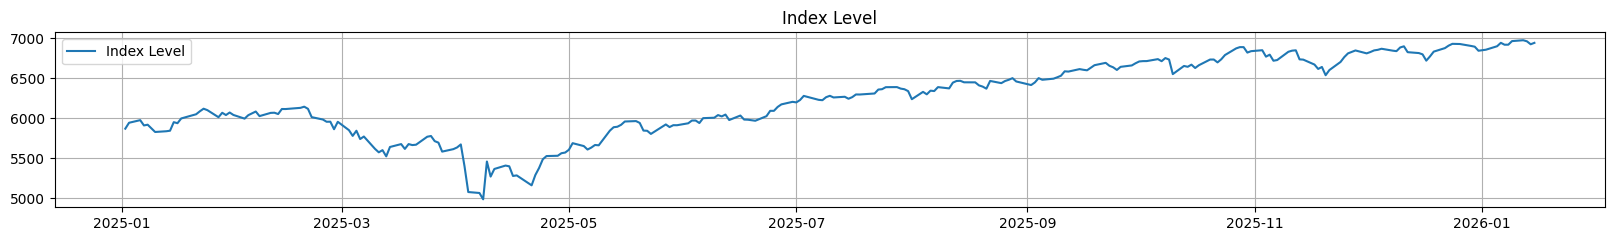

In [103]:
# Figure 1
plt.title('Backtesting of Analytical VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['Forward10dReturn'], color='BLACK', marker='x')
plt.legend(["99% 10D VaR", "Realised forward 10D return", "Breach"])
plt.grid()

# Figure 2
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

### Answer 3.c

Using the binomial distribution $B \sim \mathrm{Binomial}(T, 0.01)$, where $T = 260$ is the number of valid backtesting observations:

- Green zone: $0 \leq b \leq q_{0.95}$
- Yellow zone: $q_{0.95} < b \leq q_{0.9999}$
- Red zone: $b > q_{0.9999}$

Since the observed breach count is 10, the model falls within the **yellow** zone.

In [104]:
from scipy.stats import binom
q_green = binom.ppf(0.95, total_count, 0.01)
q_yellow = binom.ppf(0.9999, total_count, 0.01)
print(f'Green zone: [0 to {q_green:.0f}] breaches')
print(f'Yellow zone: ({q_green+1:.0f} to {q_yellow:.0f}] breaches')
print(f'Red zone: ({q_yellow:.0f}, max) breaches')

Green zone: [0 to 5] breaches
Yellow zone: (6 to 10] breaches
Red zone: (10, max) breaches


---

# Task 4

## Answer 4.a

Following the same backtesting logic as in Task 3, this question compares the predicted 10-day 99% VaR with the realised forward 10-day log return.

The daily log return is defined as
$$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right).$$

For Task 4, volatility is modelled using an EWMA specification. Let $\sigma_t^2$ denote the variance estimate on date $t$. With decay factor $\lambda$, the variance is updated recursively by

$$\sigma_{t+1|t}^2 = \lambda\sigma_{t|t-1}^2 + (1-\lambda)r_t^2$$

The corresponding 10-day VaR forecast is
$$\mathrm{VaR}^{(10)}_t = \Phi^{-1}(0.01)\, \sigma_t \sqrt{10}.$$

As stated in the question, the realised forward-looking 10-day return is computed as
Tforward 10-day log return is computed as
$$r^{10D}_t = \ln\left(\frac{S_{t+10}}{S_{t}}\right)$$

A breach occurs whenever
$$r^{10D}_t < \mathrm{VaR}_t$$

The implementation is given below.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define the relevant constants.

In [106]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load the index data from the Excel file.

In [107]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [108]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute the realised forward 10-day log return.

In [109]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-10) / data['^GSPC'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875
2015-10-16,2033.109985,4438.620117,0.004560,0.022494
2015-10-19,2033.660034,4462.069824,0.000271,0.034027
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Restrict the sample to the period from 2025-01-01 to 2026-01-15. 

In [110]:
data = data.loc['2025-01-01':'2026-01-15'].copy()
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595
2025-01-03,5942.470215,21326.160156,0.012517,0.017808
2025-01-06,5975.379883,21559.500000,0.005523,0.018404
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870
2025-01-08,5918.250000,21180.970703,0.001559,0.030451
...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307
2026-01-12,6977.270020,25787.660156,0.001576,0.000191
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050


To initialise the EWMA recursion, use the average squared daily log return over this same sample period.

Compute the initial variance as the average of squared daily log returns over the selected backtesting sample.

In [111]:
initial_variance = (data['LogReturn'].dropna() ** 2).mean()
print(f'Initial variance from the backtesting sample squared returns: {initial_variance:.6f}')

Initial variance from the backtesting sample squared returns: 0.000133


Use this sample average as the first EWMA variance estimate, and then update the remaining observations recursively.

With decay parameter $\lambda = 0.72$, the recursion is
$$\sigma_{t+1|t}^2 = \lambda\sigma_{t|t-1}^2 + (1-\lambda)r_t^2$$

In [112]:
param = 0.72

data.loc[data.index[0], 'variance'] = initial_variance

for i in range(1, len(data)):
    variance = param * data.loc[data.index[i - 1], 'variance'] + (1 - param) * data.loc[data.index[i - 1], 'LogReturn']**2
    data.loc[data.index[i], 'variance'] = variance

data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance
Date,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100
...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018


In [113]:
data['SD'] = np.sqrt(data['variance'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD
Date,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133,0.011540
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097,0.009863
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114,0.010673
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091,0.009516
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100,0.010006
...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018,0.004205
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024,0.004939
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018,0.004273


Compute the 10-day VaR series, retain the valid backtesting observations, and construct the breach indicator.

In [114]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
backtest_data = data.dropna(subset=['VaR', 'Forward10dReturn']).copy()
total_count = backtest_data.shape[0]
print(f'Total number of valid backtesting observations: {total_count}')
backtest_data

Total number of valid backtesting observations: 260


,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133,0.011540,-0.084896,0
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097,0.009863,-0.072556,0
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114,0.010673,-0.078515,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091,0.009516,-0.070005,0
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100,0.010006,-0.073606,0
...,...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018,0.004205,-0.030931,0
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024,0.004939,-0.036334,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018,0.004273,-0.031435,0


Extract the rows corresponding to VaR breaches.

In [115]:
data_breach = backtest_data[backtest_data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 11


,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-02-18,6129.580078,22164.609375,0.002442,-0.059043,0.000036,0.005981,-0.044001,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.050319,0.000027,0.005237,-0.038527,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.063955,0.000021,0.004618,-0.033972,1
2025-02-21,6013.129883,21614.080078,-0.017211,-0.041239,0.000021,0.004543,-0.033420,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.066507,0.000077,0.008796,-0.064707,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.061768,0.000062,0.007865,-0.057863,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.059764,0.000045,0.006674,-0.049101,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.110613,0.000115,0.010741,-0.079019,1
2025-03-24,5767.569824,20180.449219,0.017492,-0.130440,0.000083,0.009125,-0.067126,1


In [116]:
print(f'Count of breaches: {breach_count}, total count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 11, total count: 260, breach percentage: 4.23%


Hence, the valid backtesting sample contains 12 VaR breaches, corresponding to 4.63% of the 259 valid observations.

---

## Answer 4.b

Two plots are shown below.

The first plot compares the predicted 10-day EWMA VaR with the realised forward 10-day return and highlights the breach observations with black crosses.

The second plot shows the S&P 500 index level over the same sample period.

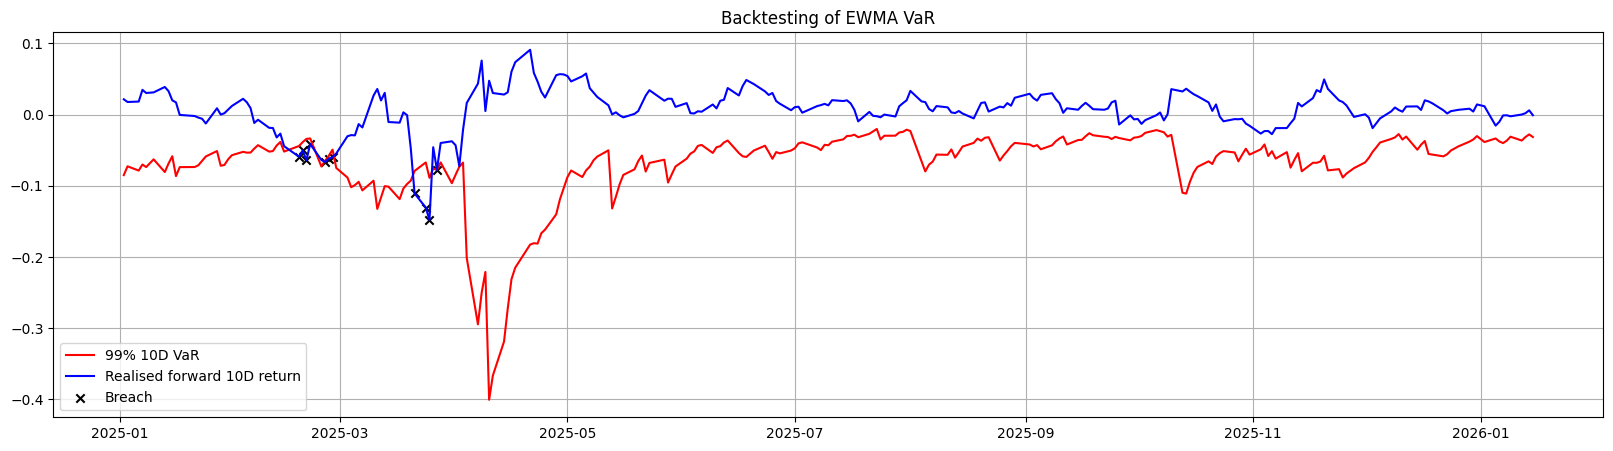

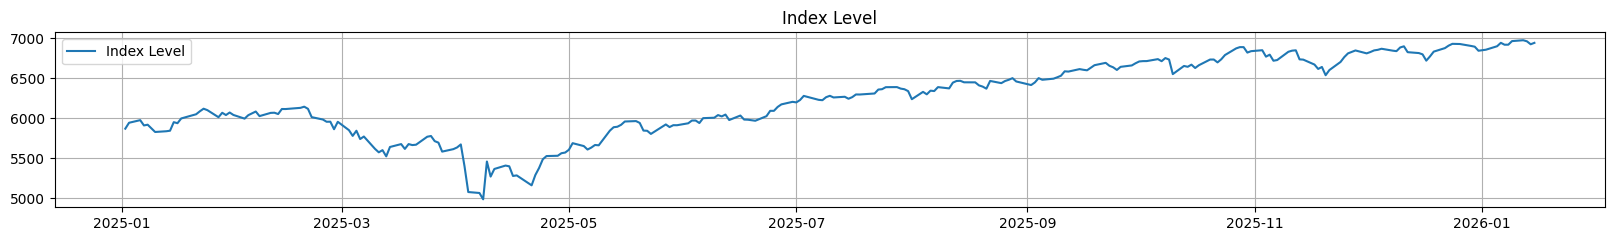

In [117]:
plt.title('Backtesting of EWMA VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['Forward10dReturn'], color='BLACK', marker='x')
plt.legend(["99% 10D VaR", "Realised forward 10D return", "Breach"])
plt.grid()

fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

## Answer 4.c

Among the three approaches, EWMA is the most adaptive because it places exponentially greater weight on recent returns and therefore responds most quickly to volatility changes.

The rolling-window method is less adaptive, since all observations inside the window receive equal weight and older information disappears only when it leaves the window.

Historical simulation is the least adaptive, because it relies on the empirical distribution of past returns and does not model volatility dynamics explicitly.